# Análisis de vulnerabilidades y componentes de la organización Vercel

## Introducción

Este notebook presenta un descriptivo de los resultados obtenidos durante la extracción realizada por el _miner_ a los 25 proyectos más populares de Vercel.
Por tanto, se analizarán los datos integrandos por el SBOM, posteriormente el análisis estático de cada repositorio, y finalmente las vulnerabilidades encontradas en las dependencias.

### Configuración inicial

La siguiente fracción de código establece los directorios para obtener la información requerida.

In [3]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Setup de rutas
PROYECT_ROOT = Path().cwd().parent
RESULTS_FOLDER = PROYECT_ROOT / "results"

print(f"Directorio de resultados: {RESULTS_FOLDER}")
print(f"Proyecto raíz: {PROYECT_ROOT}")

Directorio de resultados: /workspaces/Proyecto-Ciberseguridad/results
Proyecto raíz: /workspaces/Proyecto-Ciberseguridad


## Componentes, librerías y modulos utilizados: SBOMS

In [4]:
# Cargar datos de SBOMs
sboms_files = sorted(RESULTS_FOLDER.glob("*-sbom.json"))

print(f"Buscando archivos SBOMS en: {RESULTS_FOLDER}")
print(f"Archivos SBOMS encontrados: {len(sboms_files)}")

sboms_data = []

for file in sboms_files:
    print(f"Cargando SBOM desde: {file}")
    repo_name = file.stem.replace("-sbom", "")
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
    for artifact in data.get("artifacts", []):
        sboms_data.append({
            "repo": repo_name,
            "artifact_name": artifact.get("name"),
            "artifact_version": artifact.get("version"),
            "artifact_type": artifact.get("type"),
            "purl": artifact.get("purl"),
            "language": artifact.get("language"),
            "dependencies_count": len(artifact.get("dependencies", [])),
            "licenses": artifact.get("licenses", [])
        })

sboms_df = pd.DataFrame(sboms_data)
sboms_df.head()

Buscando archivos SBOMS en: /workspaces/Proyecto-Ciberseguridad/results
Archivos SBOMS encontrados: 21
Cargando SBOM desde: /workspaces/Proyecto-Ciberseguridad/results/chatbot-sbom.json
Cargando SBOM desde: /workspaces/Proyecto-Ciberseguridad/results/commerce-sbom.json
Cargando SBOM desde: /workspaces/Proyecto-Ciberseguridad/results/hazel-sbom.json
Cargando SBOM desde: /workspaces/Proyecto-Ciberseguridad/results/hyper-sbom.json
Cargando SBOM desde: /workspaces/Proyecto-Ciberseguridad/results/kirimase-sbom.json
Cargando SBOM desde: /workspaces/Proyecto-Ciberseguridad/results/micro-sbom.json
Cargando SBOM desde: /workspaces/Proyecto-Ciberseguridad/results/ms-sbom.json
Cargando SBOM desde: /workspaces/Proyecto-Ciberseguridad/results/ncc-sbom.json
Cargando SBOM desde: /workspaces/Proyecto-Ciberseguridad/results/next-app-router-playground-sbom.json
Cargando SBOM desde: /workspaces/Proyecto-Ciberseguridad/results/next-forge-sbom.json
Cargando SBOM desde: /workspaces/Proyecto-Ciberseguridad/r

,repo,artifact_name,artifact_version,artifact_type,purl,language,dependencies_count,licenses
0,chatbot,@ai-sdk/gateway,3.0.66,npm,pkg:npm/%40ai-sdk/gateway@3.0.66,javascript,0,[]
1,chatbot,@ai-sdk/provider,3.0.3,npm,pkg:npm/%40ai-sdk/provider@3.0.3,javascript,0,[]
2,chatbot,@ai-sdk/provider,3.0.8,npm,pkg:npm/%40ai-sdk/provider@3.0.8,javascript,0,[]
3,chatbot,@ai-sdk/provider-utils,4.0.19,npm,pkg:npm/%40ai-sdk/provider-utils@4.0.19,javascript,0,[]
4,chatbot,@ai-sdk/react,3.0.118,npm,pkg:npm/%40ai-sdk/react@3.0.118,javascript,0,[]


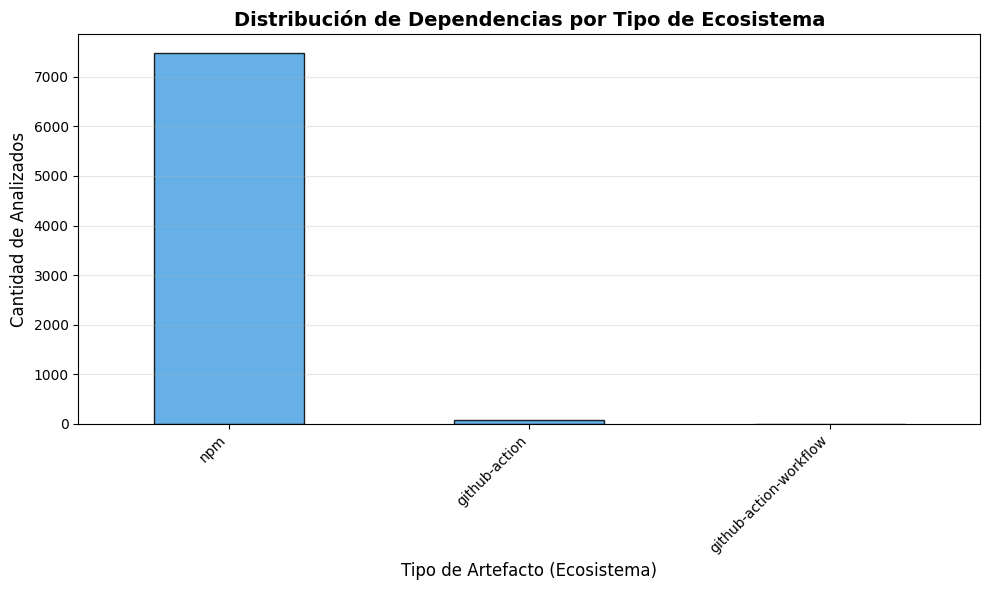

Datos de SBOM exportados a: /workspaces/Proyecto-Ciberseguridad/results/sbom-analisis/sbom-ecosistemas.json


In [5]:
if len(sboms_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    type_counts = sboms_df['artifact_type'].value_counts()

    type_counts.plot(kind='bar', ax=ax, color='#4ba3e3', edgecolor='black', alpha=0.85)

    ax.set_title('Distribución de Dependencias por Tipo de Ecosistema', fontsize=14, fontweight='bold')
    ax.set_xlabel('Tipo de Artefacto (Ecosistema)', fontsize=12)
    ax.set_ylabel('Cantidad de Analizados', fontsize=12)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    export_sbom = {
        "total_repos": int(sboms_df['repo'].nunique()),
        "ecosystems": []
    }

    for artifact_type, count in type_counts.items():
        export_sbom["ecosystems"].append({
            "type": str(artifact_type),
            "count": int(count)
        })

    output_sbom_path = RESULTS_FOLDER / "sbom-analisis" / "sbom-ecosistemas.json" 
    with open(output_sbom_path, 'w', encoding='utf-8') as f:
        json.dump(export_sbom, f, indent=4)

    print(f"Datos de SBOM exportados a: {output_sbom_path}")

else:
    print("No hay datos de SBOM disponibles para graficar")

Se detecta que la gran mayoría de dependencias son de _npm_, seguidas por las de _rust_.

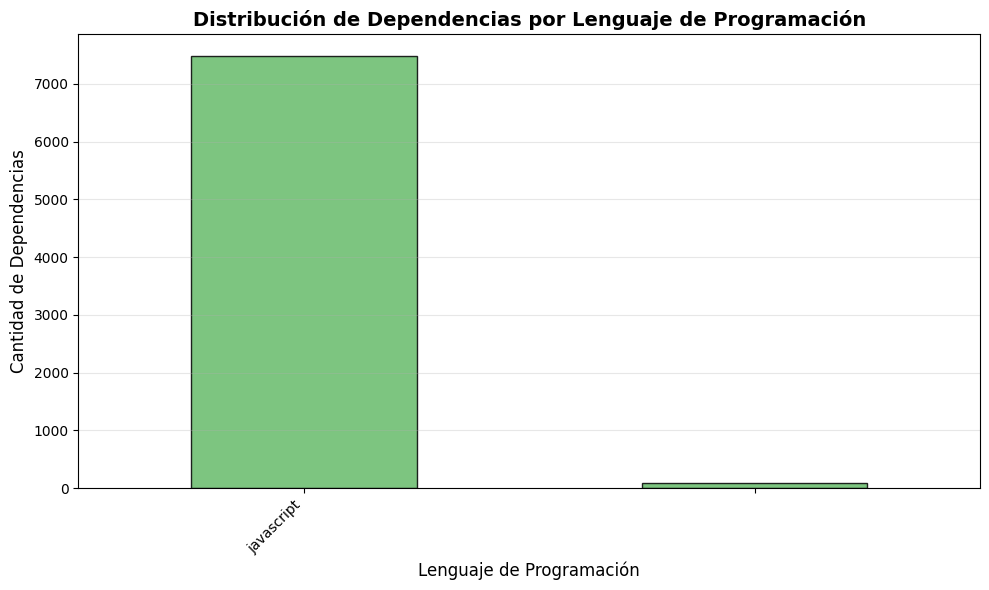

Datos de lenguajes SBOM exportados a: /workspaces/Proyecto-Ciberseguridad/results/sbom-analisis/sbom-lenguajes.json


In [6]:
if len(sboms_df) > 0 and 'language' in sboms_df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    lang_counts = sboms_df['language'].dropna().value_counts()
    lang_counts.plot(kind='bar', ax=ax, color='#66bb6a', edgecolor='black', alpha=0.85)
    ax.set_title('Distribución de Dependencias por Lenguaje de Programación', fontsize=14, fontweight='bold')
    ax.set_xlabel('Lenguaje de Programación', fontsize=12)
    ax.set_ylabel('Cantidad de Dependencias', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    export_lang = []
    for lang, count in lang_counts.items():
        if str(lang).strip(): 
            export_lang.append({
                "language": str(lang),
                "count": int(count)
            })
    
    output_lang_path = RESULTS_FOLDER / "sbom-analisis" /"sbom-lenguajes.json"
    with open(output_lang_path, 'w', encoding='utf-8') as f:
        json.dump(export_lang, f, indent=4)
        
    print(f"Datos de lenguajes SBOM exportados a: {output_lang_path}")

else:
    print("No hay datos disponibles para graficar.")

De forma análoga a lo anterior, se muestra la misma distribución de la frecuencia de los lenguajes de programación.

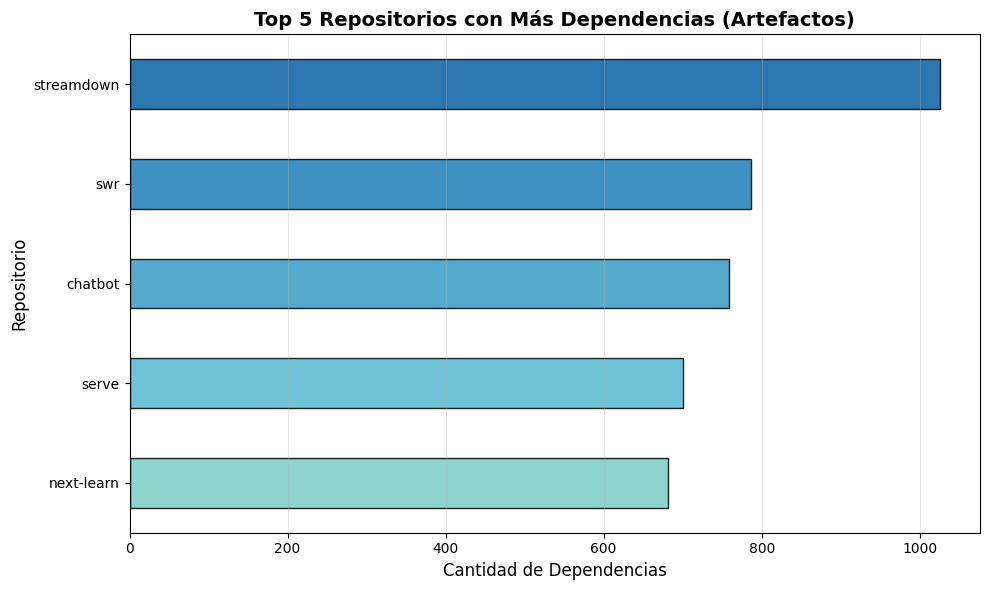

Datos del Top 5 repositorios SBOM exportados a: /workspaces/Proyecto-Ciberseguridad/results/sbom-analisis/sbom-top-repos.json


In [7]:
if len(sboms_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    top_repos = sboms_df['repo'].value_counts().head(5)
    colores = plt.cm.GnBu(np.linspace(0.5, 0.9, len(top_repos)))
    top_repos_sorted = top_repos.sort_values(ascending=True)
    top_repos_sorted.plot(kind='barh', ax=ax, color=colores, edgecolor='black', alpha=0.85)

    ax.set_title('Top 5 Repositorios con Más Dependencias (Artefactos)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Dependencias', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    export_top_repos = []
    for repo, count in top_repos.items():
        export_top_repos.append({
            "repo": str(repo),
            "count": int(count)
        })

    output_repo_path = RESULTS_FOLDER / "sbom-analisis" /"sbom-top-repos.json"
    with open(output_repo_path, 'w', encoding='utf-8') as f:
        json.dump(export_top_repos, f, indent=4)

    print(f"Datos del Top 5 repositorios SBOM exportados a: {output_repo_path}")

else:
    print("No hay datos de SBOM disponibles para analizar")

En base a los 5 repositorios con más dependencias se destancan los siguientes:
- _Vercel_: permite realizar _deploys_ de forma sencilla (SaaS).
- _examples_: provee instancias de inicialización o soluciones para orientar sobre el funcionamiento de _Vercel_.
- _Next.js_: un _framework_ de _React_ que extiende sus características y es integrado con tooling de Javascript con Rust para acelerar sus builds.

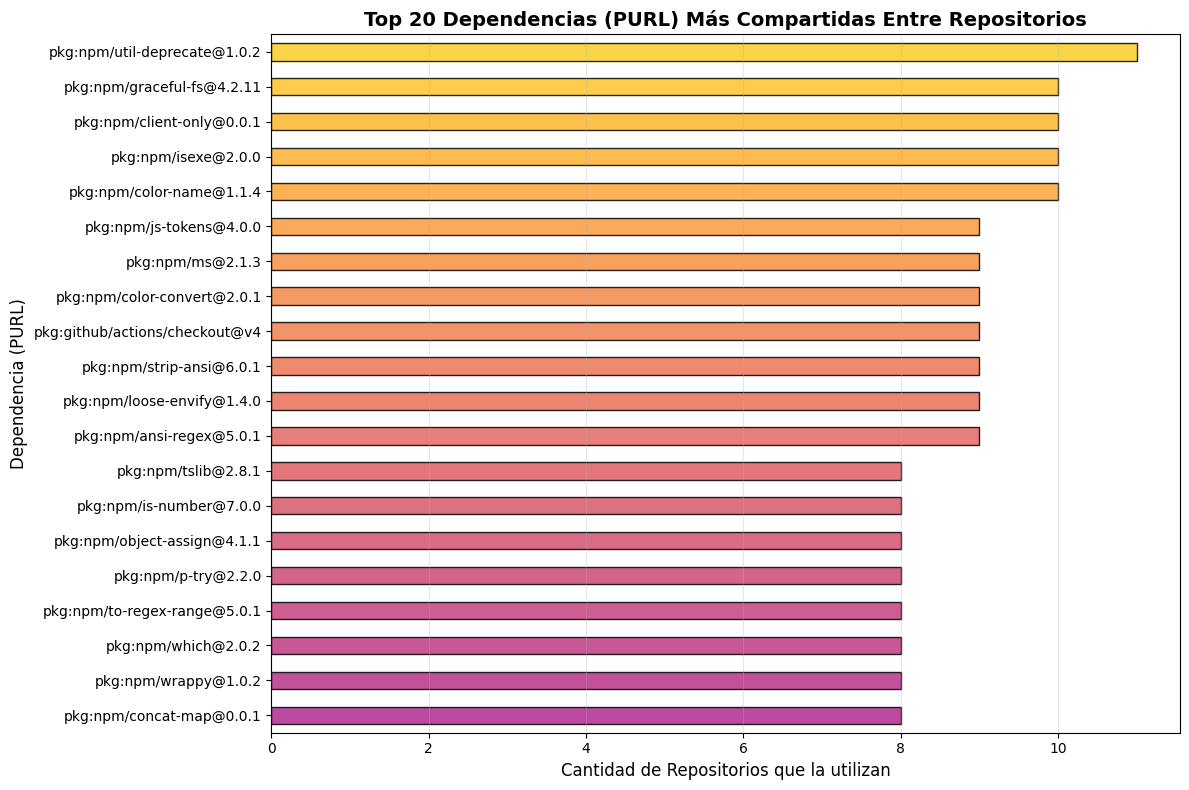

Datos de PURLs más compartidos exportados a: /workspaces/Proyecto-Ciberseguridad/results/sbom-analisis/sbom-purls.json


In [8]:
if len(sboms_df) > 0 and 'purl' in sboms_df.columns:
    fig, ax = plt.subplots(figsize=(12, 8))

    common = (
        sboms_df.dropna(subset=["purl"])
        .groupby("purl")["repo"].nunique()
        .sort_values(ascending=False)
    ).head(20)
    
    common_sorted = common.sort_values(ascending=True)
    colores = plt.cm.plasma(np.linspace(0.4, 0.9, len(common_sorted)))
    common_sorted.plot(kind='barh', ax=ax, color=colores, edgecolor='black', alpha=0.85)

    ax.set_title('Top 20 Dependencias (PURL) Más Compartidas Entre Repositorios', fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Repositorios que la utilizan', fontsize=12)
    ax.set_ylabel('Dependencia (PURL)', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    export_purls = []
    for purl, count in common.items():
        export_purls.append({
            "purl": str(purl),
            "count": int(count)
        })

    output_purls_path = RESULTS_FOLDER / "sbom-analisis" /"sbom-purls.json"
    with open(output_purls_path, 'w', encoding='utf-8') as f:
        json.dump(export_purls, f, indent=4)

    print(f"Datos de PURLs más compartidos exportados a: {output_purls_path}")

else:
    print("No hay datos de 'purl' disponibles para analizar en sboms_df")

Al análizar las 20 dependencias más compartidas entre repositorios se puede apreciar una tendencia ligada a dependencias del ecosistema de _JavaScript_, las cuales en general mejoran _Node.js_ por medio de funcionalidades extra como marcar funciones obsoletas, lista-diccionario para mapear nombres de colores a sus códigos HEX y RGB, o client-only que evita importar código de componentes de tipo client-side a server-side rendering.

## Análisis CodeQL: Vulnerabilidades en Código Fuente

In [9]:
# Cargar todos los análisis CodeQL
codeql_files = sorted(RESULTS_FOLDER.glob("*-codeql.json"))

print(f"\nBuscando archivos CodeQL en: {RESULTS_FOLDER}")
print(f"Archivos encontrados: {len(codeql_files)}\n")

data_consolidado = []

for archivo in codeql_files:
    with open(archivo, 'r', encoding='utf-8') as f:
        contenido = json.load(f)

    repo_name = archivo.stem.replace('-codeql', '')
    issues = contenido.get('issues', [])

    for issue in issues:
        issue['repo'] = repo_name
        data_consolidado.append(issue)

df_codeql = pd.DataFrame(data_consolidado)

print(f"Total de problemas cargados: {len(df_codeql)}")
print(
    f"Repositorios únicos: {df_codeql['repo'].nunique() if len(df_codeql) > 0 else 0}\n")


Buscando archivos CodeQL en: /workspaces/Proyecto-Ciberseguridad/results
Archivos encontrados: 17

Total de problemas cargados: 6470
Repositorios únicos: 16



Si bien se analizaron 25 repositorios,  solo se crearon 16 archivos codeql, ya que 9 de los repositorios no contaban con vulnerabilidades. 

In [10]:
# Estadísticas por severidad
if len(df_codeql) > 0:
    stats_severity = df_codeql['level'].value_counts().sort_index(ascending=False)

    print("Problemas por Nivel de Severidad:")
    print("=" * 50)
    for nivel, cantidad in stats_severity.items():
        porcentaje = (cantidad / len(df_codeql)) * 100
        print(f"{nivel.upper()}: {cantidad} ({porcentaje:.1f}%)")

    df_export = stats_severity.reset_index()
    df_export.columns = ['level', 'count']
    
    output_path = RESULTS_FOLDER / "codeql-analisis" / "estadisticas-severidad.json"
    df_export.to_json(output_path, orient='records', indent=4)
    print(f"\nDatos de severidad exportados a: {output_path}")

else:
    print("No hay datos de CodeQL disponibles")

Problemas por Nivel de Severidad:

Datos de severidad exportados a: /workspaces/Proyecto-Ciberseguridad/results/codeql-analisis/estadisticas-severidad.json


En total, se encontraron 6470 vulnerabilidades, de las cuales el 100% fueron catalogadas como WARNING.

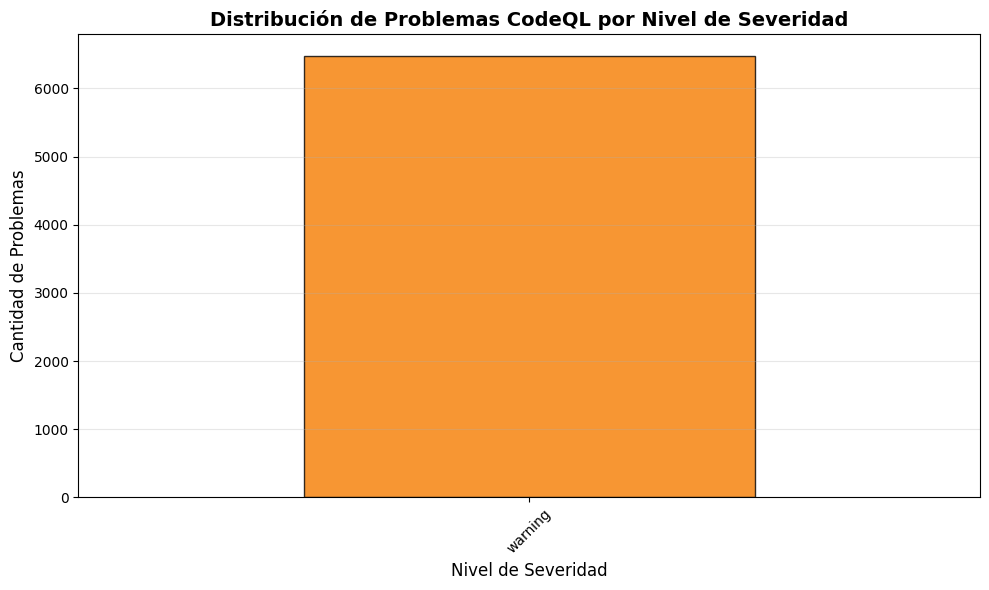

In [11]:
# Gráfico: Distribución por severidad
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    stats_severity = df_codeql['level'].value_counts(
    ).sort_index(ascending=False)

    colores = {'error': '#d32f2f', 'warning': '#f57c00', 'note': '#7cb342'}
    color_list = [colores.get(nivel, '#757575')
                  for nivel in stats_severity.index]

    stats_severity.plot(kind='bar', ax=ax, color=color_list,
                        edgecolor='black', alpha=0.8)

    ax.set_title('Distribución de Problemas CodeQL por Nivel de Severidad',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Nivel de Severidad', fontsize=12)
    ax.set_ylabel('Cantidad de Problemas', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para graficar")

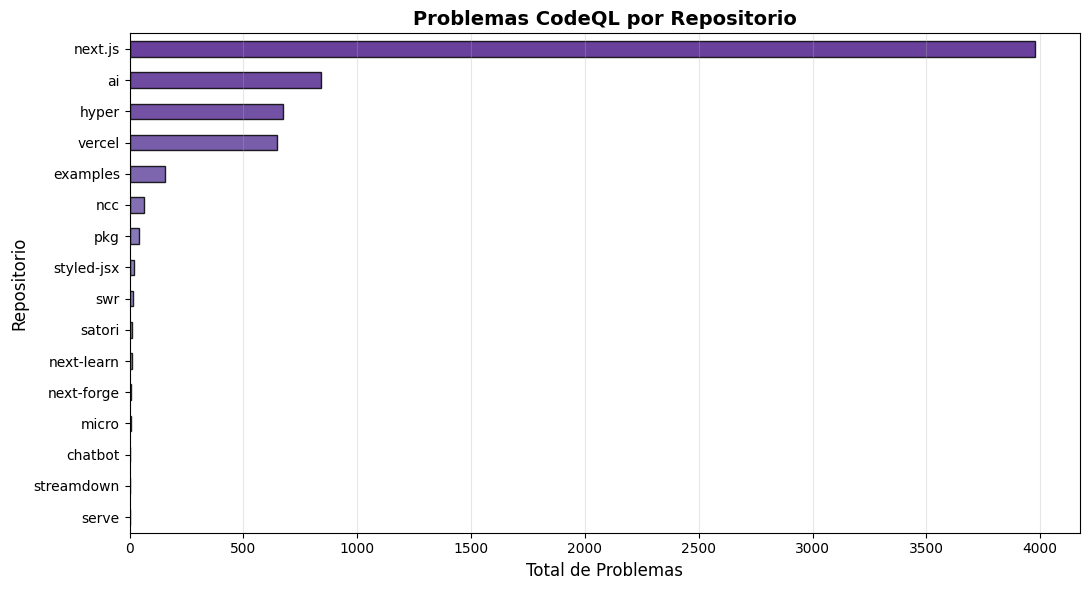

Datos por repositorio exportados a: /workspaces/Proyecto-Ciberseguridad/results/codeql-analisis/estadisticas-repo.json


In [12]:
# Gráfico: Problemas por repositorio (CodeQL)
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    issues_por_repo_series = df_codeql['repo'].value_counts().sort_values(ascending=True)

    colores_gradiente = plt.cm.Purples(np.linspace(0.4, 0.9, len(issues_por_repo_series)))

    issues_por_repo_series.plot(
        kind='barh', ax=ax, color=colores_gradiente, edgecolor='black', alpha=0.85
    )

    ax.set_title('Problemas CodeQL por Repositorio', fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Problemas', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    df_repo_export = df_codeql['repo'].value_counts().reset_index()
    df_repo_export.columns = ['repo', 'count']

    output_repo_path = RESULTS_FOLDER / "codeql-analisis" / "estadisticas-repo.json"
    df_repo_export.to_json(output_repo_path, orient='records', indent=4)
    print(f"Datos por repositorio exportados a: {output_repo_path}")

else:
    print("No hay datos disponibles para graficar ni exportar")

En el gráfico se observa que el repositorio que presenta la mayor cantidad corresponde a “next.js2” con casi 4000 vulnerabilidades, seguido por “ai” que cuenta con aproximadamente 800.

In [13]:
# Top 5 reglas más comunes
if len(df_codeql) > 0:
    top_rules = df_codeql['rule_id'].value_counts().head(5)

    print("\nTop 5 Reglas de Seguridad Más Frecuentes:")
    print("=" * 70)
    for idx, (rule, count) in enumerate(top_rules.items(), 1):
        porcentaje = (count / len(df_codeql)) * 100
        print(f"{idx:2d}. {rule:40s} {count:3d} ({porcentaje:5.1f}%)")

    df_rules_export = top_rules.reset_index()
    df_rules_export.columns = ['rule_id', 'count']

    output_rules_path = RESULTS_FOLDER / "codeql-analisis" / "estadisticas-reglas.json"
    df_rules_export.to_json(output_rules_path, orient='records', indent=4)
    print(f"\nDatos de reglas exportados a: {output_rules_path}")

else:
    print("No hay datos disponibles")


Top 5 Reglas de Seguridad Más Frecuentes:
 1. js/unused-local-variable                 2031 ( 31.4%)
 2. js/useless-assignment-to-local           605 (  9.4%)
 3. js/useless-expression                    526 (  8.1%)
 4. js/superfluous-trailing-arguments        517 (  8.0%)
 5. js/trivial-conditional                   314 (  4.9%)

Datos de reglas exportados a: /workspaces/Proyecto-Ciberseguridad/results/codeql-analisis/estadisticas-reglas.json


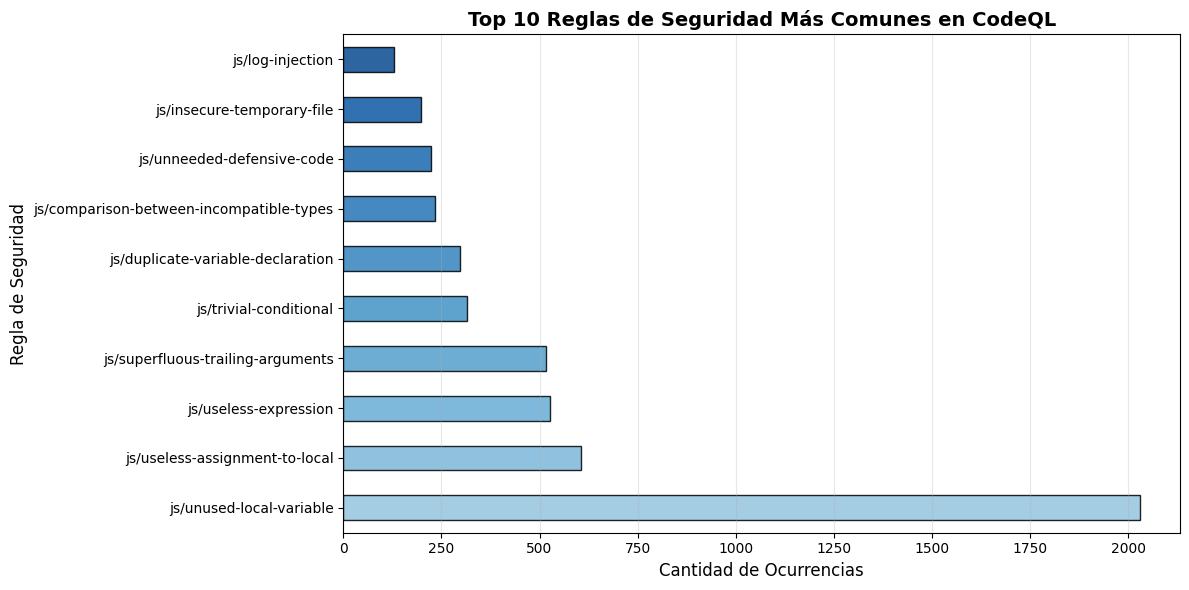

In [14]:
# Gráfico: Top 10 reglas más comunes
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))

    top_rules = df_codeql['rule_id'].value_counts().head(10)

    colores_gradiente = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_rules)))

    top_rules.plot(kind='barh', ax=ax, color=colores_gradiente,
                   edgecolor='black', alpha=0.85)

    ax.set_title('Top 10 Reglas de Seguridad Más Comunes en CodeQL',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Ocurrencias', fontsize=12)
    ax.set_ylabel('Regla de Seguridad', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para graficar")

A continuación se mencionan los 5 problemas más comunes del código fuente:
1. **js/unused-local-variable**: Corresponde a un problema en el cual se crean variables locales las cuales no son utilizadas en ningún momento del programa lo que puede causar problemas de rendimiento. Esto puede llegar a ser síntoma de un error causado en el programa como una refactorización incompleta.

2. **js/useless-assignment-to-local**: Consiste en una variable a la cual se le asigna un valor, pero este nunca es leído posteriormente. Esto puede ser debido a que el valor es sobreescrito antes de ser leído, que la asignación no tiene efecto, un error lógico en el código o código faltante.

3. **js/useless-expression**: Useless expression hace referencia a una expresión que no tienen ningún efecto en el código, como producir un output o cambiar valores, ocurriendo en un contexto donde el valor es posiblemente ignorado, indicando una posible falta de código o un bug latente.

4. **js/superfluous-trailing-arguments**: Superfluous trailing arguments corresponde a llamadas a funciones donde se pasan más argumentos de los que son declarados, por lo que los argumentos adicionales sólo pueden ser accedidos mediante el objeto arguments, así que estos quedan inutilizables si la función no contiene ni usa el objeto. Esto puede provocar una refactorización incompleta o malentendidos del funcionamiento.

5. **js/trivial-conditional**: Trivial conditional consiste de una condición designada siempre es evaluada como verdadera o falsa lo que la vuelve inutil. Esto suele ocurrir cuando se encuentra código incompleto o un error latente.

In [15]:
# 5 reglas mas comunes por repositorio
if len(df_codeql) > 0:
    reglas_por_repo = df_codeql.groupby('repo')['rule_id'].value_counts().unstack(fill_value=0)
 
    print("\nTop 5 Reglas de Seguridad Más Comunes por Repositorio:")
    print("=" * 80)
    
    export_data = []

    for repo in reglas_por_repo.index:
        print(f"{repo:30s}")
        print("-" * 80)

        top_rules = reglas_por_repo.loc[repo].sort_values(ascending=False).head(5)
        rules_list = []
        
        for rule, count in top_rules.items():
            if count > 0:
                porcentaje = (count / df_codeql[df_codeql['repo'] == repo].shape[0]) * 100
                print(f"   - {rule:40s} {count:3d} ({porcentaje:5.1f}%)")
                
                rules_list.append({
                    "rule_id": rule, 
                    "count": int(count),
                    "percentage": round(porcentaje, 1)
                })
        print()
        
        if rules_list:
            export_data.append({
                "repo": repo,
                "rules": rules_list
            })
            
    output_repo_rules_path = RESULTS_FOLDER / "codeql-analisis" / "estadisticas-repo-reglas.json"
    with open(output_repo_rules_path, 'w', encoding='utf-8') as f:
        json.dump(export_data, f, indent=4)
        
    print(f"Datos anidados exportados a: {output_repo_rules_path}")

else:
    print("No hay datos disponibles")


Top 5 Reglas de Seguridad Más Comunes por Repositorio:
ai                            
--------------------------------------------------------------------------------
   - js/unused-local-variable                 498 ( 59.3%)
   - js/superfluous-trailing-arguments         68 (  8.1%)
   - js/useless-expression                     57 (  6.8%)
   - js/unknown-directive                      34 (  4.0%)
   - js/regex/missing-regexp-anchor            27 (  3.2%)

chatbot                       
--------------------------------------------------------------------------------
   - js/insecure-randomness                     2 ( 66.7%)
   - js/unused-local-variable                   1 ( 33.3%)

examples                      
--------------------------------------------------------------------------------
   - js/unused-local-variable                  52 ( 33.5%)
   - js/insecure-randomness                    10 (  6.5%)
   - js/html-constructed-from-input            10 (  6.5%)
   - js/unsafe-j

In [16]:
# Top 5 reglas en el repositorio con más problemass
if len(df_codeql) > 0:
    repo_mas_problemas = df_codeql['repo'].value_counts().idxmax()
    problemas_repo_mas_problemas = df_codeql[df_codeql['repo'] == repo_mas_problemas]
    
    total_repo = len(problemas_repo_mas_problemas)
    total_general = len(df_codeql)
    porcentaje_total = (total_repo / total_general) * 100

    print(f"\nRepositorio con más problemas: {repo_mas_problemas}")
    print(f"Total de problemas: {total_repo}, un {porcentaje_total:.1f}% del total")
    print("\nTop 5 Reglas de Seguridad Más Frecuentes en este Repositorio:")
    print("=" * 70)
    
    top_rules_repo = problemas_repo_mas_problemas['rule_id'].value_counts().head(5)
    
    reglas_list = []
    for idx, (rule, count) in enumerate(top_rules_repo.items(), 1):
        porcentaje_regla = (count / total_repo) * 100
        print(f"{idx:2d}. {rule:40s} {count:3d} ({porcentaje_regla:5.1f}%)")
        
        reglas_list.append({
            "rule_id": rule,
            "count": int(count),
            "percentage": round(porcentaje_regla, 1)
        })

    export_peor_repo = {
        "repo_name": repo_mas_problemas,
        "total_issues": int(total_repo),
        "percentage_of_total": round(porcentaje_total, 1),
        "top_rules": reglas_list
    }

    output_peor_repo_path = RESULTS_FOLDER / "codeql-analisis" / "estadisticas-peor-repo.json"
    with open(output_peor_repo_path, 'w', encoding='utf-8') as f:
        json.dump(export_peor_repo, f, indent=4)
        
    print(f"\nDatos del peor repo exportados a: {output_peor_repo_path}")

else:
    print("No hay datos disponibles")


Repositorio con más problemas: next.js
Total de problemas: 3976, un 61.5% del total

Top 5 Reglas de Seguridad Más Frecuentes en este Repositorio:
 1. js/unused-local-variable                 1091 ( 27.4%)
 2. js/useless-assignment-to-local           507 ( 12.8%)
 3. js/useless-expression                    451 ( 11.3%)
 4. js/superfluous-trailing-arguments        437 ( 11.0%)
 5. js/trivial-conditional                   260 (  6.5%)

Datos del peor repo exportados a: /workspaces/Proyecto-Ciberseguridad/results/codeql-analisis/estadisticas-peor-repo.json


In [17]:
# Top 3 archivos con más vulnerabilidades por repositorio
if len(df_codeql) > 0:
    print("\nTop 3 Archivos con Más Vulnerabilidades por Repositorio:")
    print("=" * 80)
    
    export_archivos = []
    
    for repo in df_codeql['repo'].unique():
        print(f"{repo:30s}")
        print("-" * 80)

        repo_data = df_codeql[df_codeql['repo'] == repo]
        repo_total_issues = repo_data.shape[0]
        
        top_files = repo_data['file'].value_counts().head(3)
        archivos_list = []
        
        for idx, (file, count) in enumerate(top_files.items(), 1):
            porcentaje = (count / repo_total_issues) * 100
            print(f"   - {file:50s} {count:3d} ({porcentaje:5.1f}%)")
            
            archivos_list.append({
                "file_path": file,
                "count": int(count),
                "percentage": round(porcentaje, 1)
            })
        print()
        
        if archivos_list:
            export_archivos.append({
                "repo": repo,
                "files": archivos_list
            })

    output_archivos_path = RESULTS_FOLDER / "codeql-analisis" / "estadisticas-repo-archivos.json"
    with open(output_archivos_path, 'w', encoding='utf-8') as f:
        json.dump(export_archivos, f, indent=4)
        
    print(f"Datos de archivos exportados a: {output_archivos_path}")

else:
    print("No hay datos disponibles")


Top 3 Archivos con Más Vulnerabilidades por Repositorio:
ai                            
--------------------------------------------------------------------------------
   - packages/provider-utils/src/is-url-supported.test.ts  23 (  2.7%)
   - packages/workflow/src/test/agent-e2e-workflows.ts   20 (  2.4%)
   - packages/codemod/src/test/__testfixtures__/replace-usechat-input-with-state.output.ts  13 (  1.5%)

chatbot                       
--------------------------------------------------------------------------------
   - components/chat/shell.tsx                            1 ( 33.3%)
   - lib/db/utils.ts                                      1 ( 33.3%)
   - components/ui/sidebar.tsx                            1 ( 33.3%)

examples                      
--------------------------------------------------------------------------------
   - framework-boilerplates/hexo/themes/landscape/source/fancybox/jquery.fancybox.pack.js  20 ( 12.9%)
   - framework-boilerplates/hexo/themes/landscape/

## Análisis Grype: Vulnerabilidades en Dependencias

In [18]:
# Cargar todos los análisis Grype
grype_files = sorted(RESULTS_FOLDER.glob("*-grype.json"))

print(f"\nBuscando archivos Grype en: {RESULTS_FOLDER}")
print(f"✓ Archivos encontrados: {len(grype_files)}\n")

# Consolidar en un solo DataFrame
data_grype = []

for archivo in grype_files:
    with open(archivo, 'r', encoding='utf-8') as f:
        contenido = json.load(f)

    repo_name = archivo.stem.replace('-grype', '')
    vulns = contenido.get('vulnerabilities', [])

    for vuln in vulns:
        vuln['repo'] = repo_name
        data_grype.append(vuln)

df_grype = pd.DataFrame(data_grype)

print(f"Total de vulnerabilidades cargadas: {len(df_grype)}")
print(
    f"Repositorios únicos: {df_grype['repo'].nunique() if len(df_grype) > 0 else 0}\n")


Buscando archivos Grype en: /workspaces/Proyecto-Ciberseguridad/results
✓ Archivos encontrados: 25

Total de vulnerabilidades cargadas: 16971
Repositorios únicos: 23



In [19]:
# Estadísticas por severidad (con rangos CVSS)
if len(df_grype) > 0:
    stats_severity = df_grype['vuln_severity'].value_counts()

    cvss_ranges = {
        'critical': '9.0 - 10.0',
        'high': '7.0 - 8.9',
        'medium': '4.0 - 6.9',
        'low': '0.0 - 3.9'
    }

    print("Vulnerabilidades por Nivel de Severidad CVSS:")
    print("=" * 60)
    print(f"{'Severidad':<12} {'Cantidad':<10} {'Rango CVSS':<15} {'%':<8}")
    print("=" * 60)

    export_grype_sev = []

    for severidad in ['critical', 'high', 'medium', 'low']:
        cantidad = int(stats_severity.get(severidad, 0))
        porcentaje = (cantidad / len(df_grype) * 100) if len(df_grype) > 0 else 0
        rango = cvss_ranges.get(severidad, 'N/A')
        print(f"{severidad:<10} {cantidad:<10} {rango:<15} {porcentaje:>6.1f}%")

        export_grype_sev.append({
            "level": severidad,
            "count": cantidad,
            "cvss": rango,
            "percentage": round(porcentaje, 1)
        })

    print("=" * 60)
    print(f"Total general: {len(df_grype)} vulnerabilidades encontradas")

    output_grype_sev_path = RESULTS_FOLDER / "grype-analisis" /"grype-severidad.json"
    with open(output_grype_sev_path, 'w', encoding='utf-8') as f:
        json.dump(export_grype_sev, f, indent=4)
        
    print(f"\nDatos de severidad Grype exportados a: {output_grype_sev_path}")

else:
    print("No hay datos de Grype disponibles")

Vulnerabilidades por Nivel de Severidad CVSS:
Severidad    Cantidad   Rango CVSS      %       
critical   0          9.0 - 10.0         0.0%
high       0          7.0 - 8.9          0.0%
medium     0          4.0 - 6.9          0.0%
low        16971      0.0 - 3.9        100.0%
Total general: 16971 vulnerabilidades encontradas

Datos de severidad Grype exportados a: /workspaces/Proyecto-Ciberseguridad/results/grype-analisis/grype-severidad.json


Respecto al análisis con Grype realizado,  se encontraron 16971 vulnerabilidades de componentes, de las cuales todas fueron categorizadas con nivel de severidad CVSS “low” (entre 0 y 3,9).

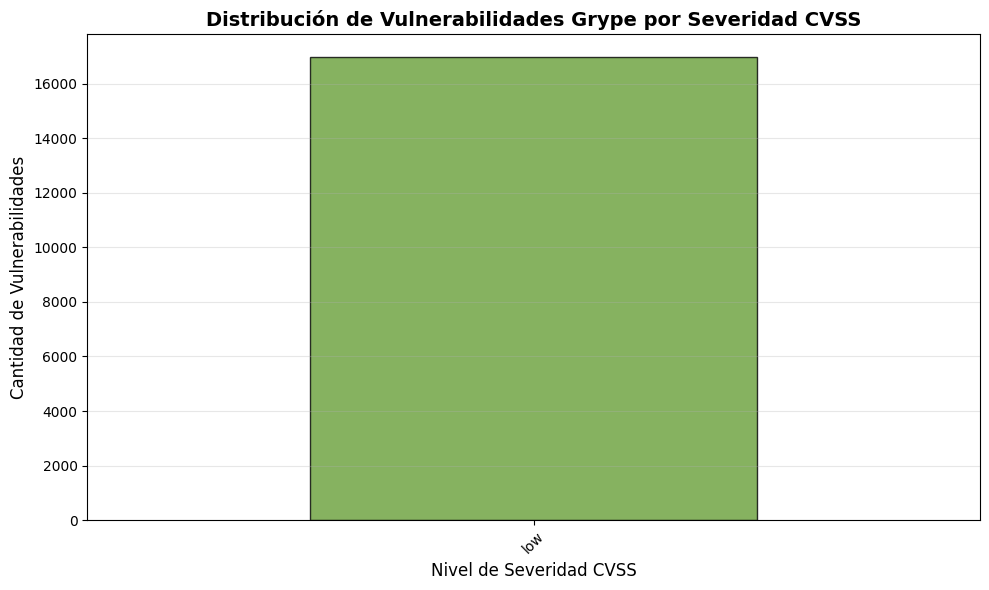

In [20]:
# Gráfico: Distribución por severidad
if len(df_grype) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    severidad_order = ['critical', 'high', 'medium', 'low']
    stats_severity = df_grype['vuln_severity'].value_counts()
    stats_severity = stats_severity.reindex(
        [s for s in severidad_order if s in stats_severity.index])

    colores = {'critical': '#b71c1c', 'high': '#e64a19',
               'medium': '#fbc02d', 'low': '#689f38'}
    color_list = [colores.get(nivel, '#757575')
                  for nivel in stats_severity.index]

    stats_severity.plot(kind='bar', ax=ax, color=color_list,
                        edgecolor='black', alpha=0.8)

    ax.set_title('Distribución de Vulnerabilidades Grype por Severidad CVSS',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Nivel de Severidad CVSS', fontsize=12)
    ax.set_ylabel('Cantidad de Vulnerabilidades', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para graficar")

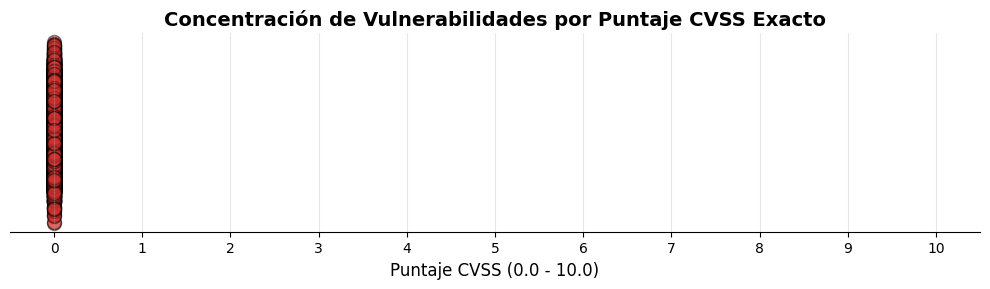

Datos de dispersión CVSS exportados a: /workspaces/Proyecto-Ciberseguridad/results/grype-analisis/grype-cvss.json


In [22]:
# Gráfico: Dispersión de puntajes CVSS (si están disponibles)
if len(df_grype) > 0 and 'cvss_score' in df_grype.columns:
    fig, ax = plt.subplots(figsize=(10, 3))

    df_cvss = df_grype[df_grype['cvss_score'].apply(lambda x: isinstance(x, (int, float)))].copy()

    if not df_cvss.empty:
        df_cvss['cvss_score'] = pd.to_numeric(df_cvss['cvss_score'], errors='coerce')

        x_vals = df_cvss['cvss_score']
        y_vals = np.ones(len(x_vals)) + np.random.normal(0, 0.05, len(x_vals))

        ax.scatter(x_vals, y_vals, color='#d32f2f', alpha=0.5, edgecolor='black', s=100)

        ax.set_title('Concentración de Vulnerabilidades por Puntaje CVSS Exacto', fontsize=14, fontweight='bold')
        ax.set_xlabel('Puntaje CVSS (0.0 - 10.0)', fontsize=12)
        
        ax.set_xlim(-0.5, 10.5)
        ax.set_xticks(range(11))
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.show()
        df_cvss_clean = df_cvss.dropna(subset=['cvss_score'])
        
        export_cvss = df_cvss_clean[['package_name', 'cvss_score', 'vuln_severity']].to_dict(orient='records')
        
        output_grype_cvss_path = RESULTS_FOLDER / "grype-analisis" / "grype-cvss.json"
        with open(output_grype_cvss_path, 'w', encoding='utf-8') as f:
            json.dump(export_cvss, f, indent=4)
            
        print(f"Datos de dispersión CVSS exportados a: {output_grype_cvss_path}")

    else:
        print("No hay puntajes CVSS válidos para graficar ni exportar")
else:
    print("No hay datos de CVSS disponibles")

Este gráfico tenía la intención de mostrar los niveles de severidad específicos, sin embargo, se teoriza que en algún punto del proceso, estos datos se perdieron o se clasificaron erróneamente como nulos, resultando en calificaciones CVSS de 0 para todas las vulnerabilidades.

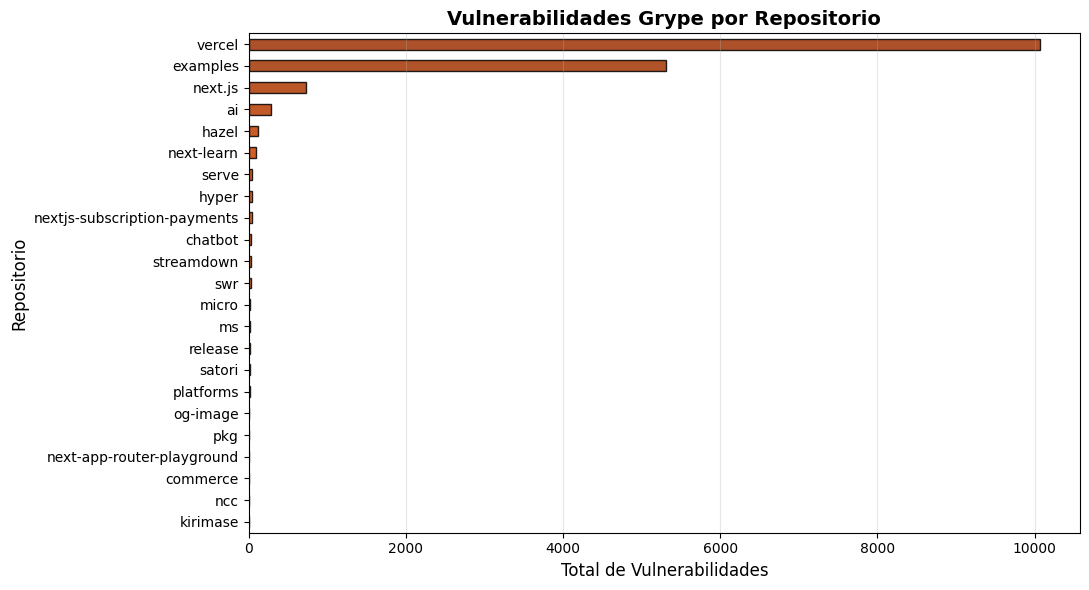

Datos de Grype por repositorio exportados a: /workspaces/Proyecto-Ciberseguridad/results/grype-analisis/grype-repo.json


In [23]:
# Gráfico: Vulnerabilidades por repositorio (Grype)
if len(df_grype) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    vulns_por_repo = df_grype['repo'].value_counts().sort_values(ascending=True)

    colores_gradiente = plt.cm.Oranges(np.linspace(0.4, 0.9, len(vulns_por_repo)))

    vulns_por_repo.plot(kind='barh', ax=ax,
                        color=colores_gradiente, edgecolor='black', alpha=0.85)

    ax.set_title('Vulnerabilidades Grype por Repositorio',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Vulnerabilidades', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    df_grype_repo_export = df_grype['repo'].value_counts().reset_index()
    df_grype_repo_export.columns = ['repo', 'count']

    output_grype_repo_path = RESULTS_FOLDER / "grype-analisis" / "grype-repo.json"
    df_grype_repo_export.to_json(output_grype_repo_path, orient='records', indent=4)
    print(f"Datos de Grype por repositorio exportados a: {output_grype_repo_path}")

else:
    print("No hay datos disponibles para graficar")

Se puede observar en el gráfico que los repositorios *vercel* y *examples* tienen una cantidad significativamente mayor de vulnerabilidades de componentes, abordando cifras de más de 10000 y más de 5000, respectivamente.

In [24]:
# Top 5 paquetes más vulnerables
if len(df_grype) > 0:
    top_packages = df_grype['package_name'].value_counts().head(10)

    print("\nTop 10 Paquetes con Más Vulnerabilidades:")
    print("=" * 80)
    print(f"{'Paquete':<30} {'Vulns':<10} {'Vers. Actual':<15} {'Fix?':<8}")
    print("=" * 80)

    for pkg_name in top_packages.index:
        pkg_data = df_grype[df_grype['package_name'] == pkg_name].iloc[0]
        cantidad = top_packages[pkg_name]
        version = pkg_data.get('current_version', 'N/A')
        fix = pkg_data.get('fix_version', 'N/A')
        fix_status = "✓ Sí" if fix != 'N/A' else "✗ No"

        print(f"{pkg_name:<30} {cantidad:<10} {str(version):<15} {fix_status:<8}")

else:
    print("No hay datos disponibles")


Top 10 Paquetes con Más Vulnerabilidades:
Paquete                        Vulns      Vers. Actual    Fix?    
next                           1596       15.0.7          ✗ No    
minimatch                      928        3.1.2           ✗ No    
axios                          749        1.6.2           ✗ No    
hono                           680        4.6.9           ✗ No    
postcss                        589        8.4.31          ✗ No    
picomatch                      548        2.3.1           ✗ No    
vite                           532        7.1.11          ✗ No    
brace-expansion                464        1.1.11          ✗ No    
tar                            444        6.2.1           ✗ No    
lodash                         375        4.17.21         ✗ No    


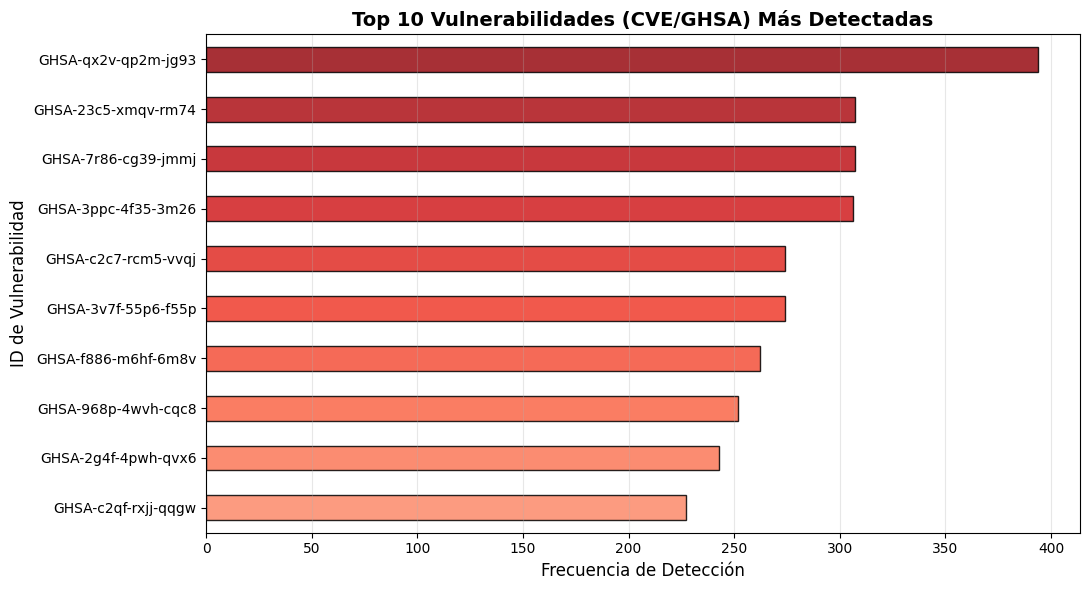


Top 10 Vulnerabilidades (Detalle en Consola):
ID: GHSA-qx2v-qp2m-jg93       | Detecciones: 394
ID: GHSA-7r86-cg39-jmmj       | Detecciones: 307
ID: GHSA-23c5-xmqv-rm74       | Detecciones: 307
ID: GHSA-3ppc-4f35-3m26       | Detecciones: 306
ID: GHSA-3v7f-55p6-f55p       | Detecciones: 274
ID: GHSA-c2c7-rcm5-vvqj       | Detecciones: 274
ID: GHSA-f886-m6hf-6m8v       | Detecciones: 262
ID: GHSA-968p-4wvh-cqc8       | Detecciones: 252
ID: GHSA-2g4f-4pwh-qvx6       | Detecciones: 243
ID: GHSA-c2qf-rxjj-qqgw       | Detecciones: 227

Datos exportados para la web en: /workspaces/Proyecto-Ciberseguridad/results/grype-analisis/grype-top-10-vulns.json


In [35]:
# Verificar que el DataFrame tenga datos
if len(df_grype) > 0:
    id_col = 'vuln_id' if 'vuln_id' in df_grype.columns else 'vulnerability_id'

    if id_col in df_grype.columns:
        fig, ax = plt.subplots(figsize=(11, 6))

        top_10_vulns = df_grype[id_col].value_counts().head(10)

        top_10_sorted = top_10_vulns.sort_values(ascending=True)

        colores = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_10_sorted)))
        
        top_10_sorted.plot(kind='barh', ax=ax, color=colores, edgecolor='black', alpha=0.85)

        ax.set_title('Top 10 Vulnerabilidades (CVE/GHSA) Más Detectadas', fontsize=14, fontweight='bold')
        ax.set_xlabel('Frecuencia de Detección', fontsize=12)
        ax.set_ylabel('ID de Vulnerabilidad', fontsize=12)
        ax.grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.show()

        print("\nTop 10 Vulnerabilidades (Detalle en Consola):")
        print("=" * 60)
        
        export_top_10 = []

        for vuln_id, count in top_10_vulns.items():
            print(f"ID: {vuln_id:25s} | Detecciones: {count}")
            export_top_10.append({
                "vuln_id": str(vuln_id),
                "count": int(count)
            })

        output_top10_path = RESULTS_FOLDER / "grype-analisis" / "grype-top-10-vulns.json"
        
        with open(output_top10_path, 'w', encoding='utf-8') as f:
            json.dump(export_top_10, f, indent=4)
            
        print(f"\nDatos exportados para la web en: {output_top10_path}")
        
    else:
        print("No se encontró la columna de IDs de vulnerabilidad ('vuln_id') en el DataFrame.")
else:
    print("No hay datos de Grype disponibles para graficar.")

In [25]:
# Top 3 paquetes más vulnerables
if len(df_grype) > 0:
    top_packages = df_grype['package_name'].value_counts().head(3)

    print("\nTop 3 Paquetes con Más Vulnerabilidades:")
    print("=" * 80)
    print(f"{'Paquete':<30} {'Vulns':<10} {'Vers. Actual':<15} {'Fix?':<8}")
    print("=" * 80)

    export_top_pkgs = []

    for pkg_name in top_packages.index:
        pkg_data = df_grype[df_grype['package_name'] == pkg_name].iloc[0]
        cantidad = int(top_packages[pkg_name])
        version = str(pkg_data.get('current_version', 'N/A'))
        fix = str(pkg_data.get('fix_version', 'N/A'))
        has_fix = fix != 'N/A'
        fix_status = "✓ Sí" if has_fix else "✗ No"

        print(f"{pkg_name:<30} {cantidad:<10} {version:<15} {fix_status:<8}")

        export_top_pkgs.append({
            "package_name": pkg_name,
            "count": cantidad,
            "current_version": version,
            "has_fix": has_fix,
            "fix_version": fix
        })

    print("=" * 80)

    output_grype_pkgs_path = RESULTS_FOLDER / "grype-analisis" / "grype-top-paquetes.json"
    with open(output_grype_pkgs_path, 'w', encoding='utf-8') as f:
        json.dump(export_top_pkgs, f, indent=4)
        
    print(f"Datos del Top 3 de paquetes exportados a: {output_grype_pkgs_path}")

else:
    print("No hay datos disponibles")


Top 3 Paquetes con Más Vulnerabilidades:
Paquete                        Vulns      Vers. Actual    Fix?    
next                           1596       15.0.7          ✗ No    
minimatch                      928        3.1.2           ✗ No    
axios                          749        1.6.2           ✗ No    
Datos del Top 3 de paquetes exportados a: /workspaces/Proyecto-Ciberseguridad/results/grype-analisis/grype-top-paquetes.json


In [26]:
paquetes = ["next", "minimatch", "axios"]

for pkg_name in paquetes:
    print(f"\nPrimera vulnerabilidad encontrada para el paquete '{pkg_name}':")
    print("=" * 80)

    pkg_vulns = df_grype[df_grype['package_name'] == pkg_name]
    
    if not pkg_vulns.empty:
        row = pkg_vulns.iloc[0]
        
        vuln_id = row.get('vuln_id', row.get('vulnerability_id', 'N/A'))
        severity = row.get('vuln_severity', 'N/A')
        current_version = row.get('current_version', 'N/A')
        fix_version = row.get('fix_version', 'N/A')
        message = row.get('message', 'Sin descripción detallada disponible.')
        repo = row.get('repo', 'N/A') 

        print(f"- Repo: {repo} | ID: {vuln_id}, Severidad: {severity}, Versión Actual: {current_version}")
        print(f"  Detalle: {message}")
    else:
        print(f"No se encontraron vulnerabilidades para '{pkg_name}'")


Primera vulnerabilidad encontrada para el paquete 'next':
- Repo: ai | ID: GHSA-f82v-jwr5-mffw, Severidad: low, Versión Actual: 15.0.7
  Detalle: Authorization Bypass in Next.js Middleware

Primera vulnerabilidad encontrada para el paquete 'minimatch':
- Repo: ai | ID: GHSA-7r86-cg39-jmmj, Severidad: low, Versión Actual: 3.1.2
  Detalle: minimatch has ReDoS: matchOne() combinatorial backtracking via multiple non-adjacent GLOBSTAR segments

Primera vulnerabilidad encontrada para el paquete 'axios':
- Repo: examples | ID: GHSA-8hc4-vh64-cxmj, Severidad: low, Versión Actual: 1.6.2
  Detalle: Server-Side Request Forgery in axios


A continuación se mencionan las 3 dependencias con más vulnerabilidades encontradas en conjunto con algunas específicas:
1. **next**: Permite crear aplicaciones web full-stack extendiendo las últimas características de *React* e integrando potentes herramientas de *JavaScript* basadas en *Rust* para lograr compilaciones más rápidas. Una de las vulnerabilidades que presenta esta dependencia tiene el código de [GHSA-f82v-jwr5-mffw](https://github.com/advisories/GHSA-f82v-jwr5-mffw) de severidad CVSS 9,1. Esta corresponde a una vulnerabilidad que se origina por un fallo de diseño en el manejo del encabezado `x-middleware-subrequest` dentro de *Next.js*. Este encabezado, pensado sólo para uso interno y evitar bucles infinitos en la ejecución de middleware, puede ser manipulado por un atacante externo para que la función `runMiddleware` omita completamente la validación del middleware. Al enviar una solicitud con el valor adecuado en dicho encabezado, es posible saltarse controles de autenticación, autorización, u otras protecciones implementadas en middleware, permitiendo que la petición llegue directamente al recurso de destino.

2. **minimatch**: Es una librería popular y ligera que se utiliza para realizar coincidencias de rutas de archivos y cadenas de texto a través de patrones al estilo *bash*. Una de las vulnerabilidades que presenta esta dependencia tiene el código de [GHSA-7r86-cg39-jmmj](https://github.com/advisories/GHSA-7r86-cg39-jmmj) de severidad CVSS 7,5. Esta corresponde a una vulnerabilidad de denegación de servicio mediante expresiones regulares de alta gravedad la cual ocurre cuando utiliza un retroceso recursivo ilimitado en múltiples segmentos.

3. **axios**: Es un cliente HTTP que proporciona una API sencilla y fácil de usar para realizar solicitudes HTTP, que es compatible con todos los navegadores modernos y se utiliza ampliamente en la comunidad JavaScript. Una de las vulnerabilidades que presenta esta dependencia tiene el código de [GHSA-8hc4-vh64-cxmj](https://github.com/advisories/GHSA-8hc4-vh64-cxmj) de severidad CVSS 7,5. Esta corresponde a una vulnerabilidad de falsificación de solicitudes del lado del servidor mediante un comportamiento inesperado donde las URL relativas a la ruta se procesan como URL relativas al protocolo.

In [27]:
# Mostrar la informacion de las vulnerabilidades del paquete kysely
if len(df_grype) > 0:
    pkg_name = "kysely"
    pkg_vulns = df_grype[df_grype['package_name'] == pkg_name]
    
    export_kysely = []

    if not pkg_vulns.empty:
        print(f"\nVulnerabilidades encontradas para el paquete '{pkg_name}':")
        print("=" * 80)
        for idx, row in pkg_vulns.iterrows():
            vuln_id = row.get('vuln_id', row.get('vulnerability_id', 'N/A'))
            severity = row.get('vuln_severity', 'N/A')
            current_version = row.get('current_version', 'N/A')
            fix_version = row.get('fix_version', 'N/A')
            message = row.get('message', 'Sin descripción detallada disponible.')
            repo = row.get('repo', 'N/A') 
            
            print(f"\n- Repo: {repo} | ID: {vuln_id}, Severidad: {severity}, Versión Actual: {current_version}")
            print(f"  Detalle: {message}")
            
            export_kysely.append({
                "vuln_id": vuln_id,
                "severity": severity,
                "current_version": str(current_version),
                "fix_version": str(fix_version),
                "message": str(message),
                "repo": str(repo)
            })
    else:
        print(f"No se encontraron vulnerabilidades para el paquete '{pkg_name}'")
        
    output_kysely_path = RESULTS_FOLDER / "grype-analisis" / "grype-kysely.json"
    with open(output_kysely_path, 'w', encoding='utf-8') as f:
        json.dump(export_kysely, f, indent=4)
        
    print(f"\nDatos del paquete {pkg_name} exportados a: {output_kysely_path}")

else:
    print("No hay datos disponibles")


Vulnerabilidades encontradas para el paquete 'kysely':

- Repo: chatbot | ID: GHSA-8cpq-38p9-67gx, Severidad: low, Versión Actual: 0.28.11
  Detalle: Kysely has a MySQL SQL Injection via Insufficient Backslash Escaping in `sql.lit(string)` usage or similar methods that append string literal values into the compiled SQL strings

- Repo: chatbot | ID: GHSA-wmrf-hv6w-mr66, Severidad: low, Versión Actual: 0.28.11
  Detalle: SQL Injection via unsanitized JSON path keys when ignoring/silencing compilation errors or using `Kysely<any>`.

- Repo: examples | ID: GHSA-8cpq-38p9-67gx, Severidad: low, Versión Actual: 0.26.3
  Detalle: Kysely has a MySQL SQL Injection via Insufficient Backslash Escaping in `sql.lit(string)` usage or similar methods that append string literal values into the compiled SQL strings

- Repo: examples | ID: GHSA-wmrf-hv6w-mr66, Severidad: low, Versión Actual: 0.26.3
  Detalle: SQL Injection via unsanitized JSON path keys when ignoring/silencing compilation errors or usi

Al equipo le llamó la atención las vulnerabilidades del componente Kysely dentro de los repositorio de *chatbot* y *examples*, que contenían dos amenazas de posibles inyecciones SQL calificadas con un CVSS de [8,1](https://github.com/advisories/GHSA-8cpq-38p9-67gx) y de [8,2](https://github.com/advisories/GHSA-wmrf-hv6w-mr66), con Vercel aún manteniendo la versión afectada por ambas, a pesar de que la primera ya ha sido corregida en la versión 0.28.14 y la segunda fue corregida en la versión 0.28.12.

In [28]:
# Repositorio con mas problemas en total y con menos, contando grype y codeql juntos.
if len(df_codeql) > 0 and len(df_grype) > 0:
    total_problemas = pd.concat([
        df_codeql.groupby('repo').size().rename('codeql_count'),
        df_grype.groupby('repo').size().rename('grype_count')
    ], axis=1).fillna(0)

    total_problemas['total'] = total_problemas['codeql_count'] + total_problemas['grype_count']

    repo_mas_problemas = total_problemas['total'].idxmax()
    repo_menos_problemas = total_problemas[total_problemas['total'] > 0]['total'].idxmin()

    print(f"\nRepositorio con más problemas (CodeQL + Grype): {repo_mas_problemas} ({int(total_problemas.loc[repo_mas_problemas, 'total'])} problemas)")
    print(f"Repositorio con menos problemas (CodeQL + Grype): {repo_menos_problemas} ({int(total_problemas.loc[repo_menos_problemas, 'total'])} problemas)")
    
    export_global = {
        "max": {
            "repo": repo_mas_problemas,
            "total": int(total_problemas.loc[repo_mas_problemas, 'total']),
            "codeql": int(total_problemas.loc[repo_mas_problemas, 'codeql_count']),
            "grype": int(total_problemas.loc[repo_mas_problemas, 'grype_count'])
        },
        "min": {
            "repo": repo_menos_problemas,
            "total": int(total_problemas.loc[repo_menos_problemas, 'total']),
            "codeql": int(total_problemas.loc[repo_menos_problemas, 'codeql_count']),
            "grype": int(total_problemas.loc[repo_menos_problemas, 'grype_count'])
        }
    }
    
    output_global_path = RESULTS_FOLDER / "grype-analisis" / "resumen-global.json"
    with open(output_global_path, 'w', encoding='utf-8') as f:
        json.dump(export_global, f, indent=4)
        
    print(f"Datos del resumen global exportados a: {output_global_path}")

else:
    print("No hay datos suficientes para determinar repositorios con más/menos problemas")


Repositorio con más problemas (CodeQL + Grype): vercel (10721 problemas)
Repositorio con menos problemas (CodeQL + Grype): kirimase (2 problemas)
Datos del resumen global exportados a: /workspaces/Proyecto-Ciberseguridad/results/grype-analisis/resumen-global.json


## Análisis de CI con CodeQL

In [29]:
# Cargar todos los análisis CodeQL
codeql_files = sorted(RESULTS_FOLDER.glob("*-pipeline.json"))

print(f"\nBuscando archivos CodeQL en: {RESULTS_FOLDER}")
print(f"✓ Archivos encontrados: {len(codeql_files)}\n")

# Consolidar en un solo DataFrame
data_consolidado = []

for archivo in codeql_files:
    with open(archivo, 'r', encoding='utf-8') as f:
        contenido = json.load(f)

    repo_name = archivo.stem.replace('-pipeline', '')
    issues = contenido.get('issues', [])

    for issue in issues:
        issue['repo'] = repo_name
        data_consolidado.append(issue)

df_codeql = pd.DataFrame(data_consolidado)

print(f"Total de problemas cargados: {len(df_codeql)}")
print(
    f"Repositorios únicos: {df_codeql['repo'].nunique() if len(df_codeql) > 0 else 0}\n")


Buscando archivos CodeQL en: /workspaces/Proyecto-Ciberseguridad/results
✓ Archivos encontrados: 17

Total de problemas cargados: 206
Repositorios únicos: 17



Respecto al análisis relacionado al CI, de los 25 repositorios incluidos, 17 encontraron problemas, mientras que los 8 restantes no presentaban CI o presentaron errores al procesar sus archivos.

In [30]:
# Estadísticas por severidad
if len(df_codeql) > 0:
    stats_severity = df_codeql['level'].value_counts().sort_index(ascending=False)

    print("Problemas por Nivel de Severidad:")
    print("=" * 50)
    
    export_ci = {
        "total_repos": int(df_codeql['repo'].nunique()),
        "total_issues": len(df_codeql),
        "severities": []
    }

    for nivel, cantidad in stats_severity.items():
        porcentaje = (cantidad / len(df_codeql)) * 100
        print(f"{nivel.upper()}: {cantidad} ({porcentaje:.1f}%)")
        
        export_ci["severities"].append({
            "level": nivel,
            "count": int(cantidad),
            "percentage": round(porcentaje, 1)
        })

    print(f"\nTotal general: {len(df_codeql)} problemas encontrados")
    
    output_ci_path = RESULTS_FOLDER / "ci-analisis" /"ci-severidad.json"
    with open(output_ci_path, 'w', encoding='utf-8') as f:
        json.dump(export_ci, f, indent=4)
        
    print(f"\nDatos de CI exportados a: {output_ci_path}")

else:
    print("No hay datos de CI/Pipeline disponibles")

Problemas por Nivel de Severidad:

Total general: 206 problemas encontrados

Datos de CI exportados a: /workspaces/Proyecto-Ciberseguridad/results/ci-analisis/ci-severidad.json


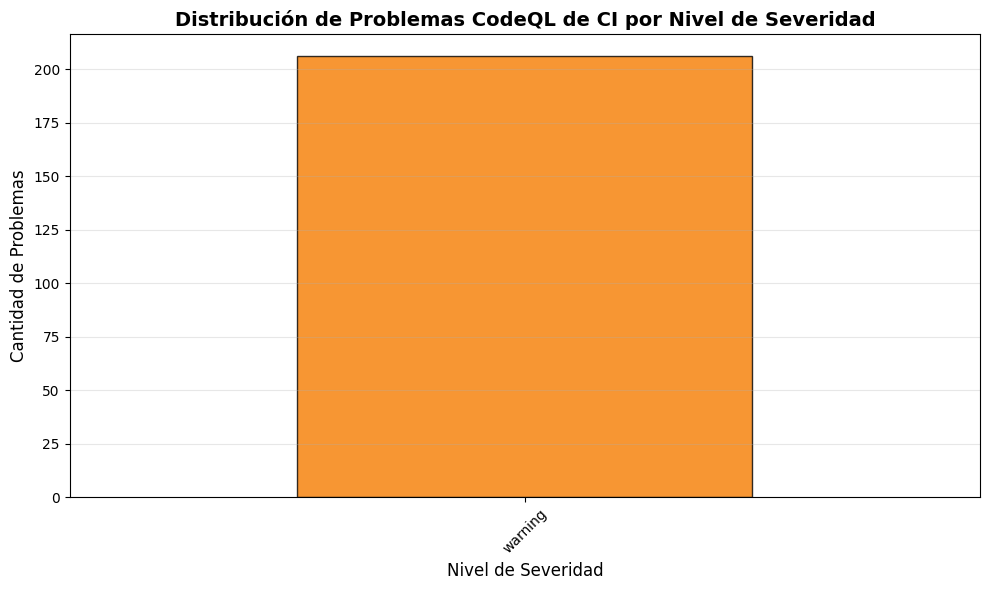

In [31]:
# Gráfico: Distribución por severidad
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    stats_severity = df_codeql['level'].value_counts(
    ).sort_index(ascending=False)

    colores = {'error': '#d32f2f', 'warning': '#f57c00', 'note': '#7cb342'}
    color_list = [colores.get(nivel, '#757575')
                  for nivel in stats_severity.index]

    stats_severity.plot(kind='bar', ax=ax, color=color_list,
                        edgecolor='black', alpha=0.8)

    ax.set_title('Distribución de Problemas CodeQL de CI por Nivel de Severidad',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Nivel de Severidad', fontsize=12)
    ax.set_ylabel('Cantidad de Problemas', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para graficar")

Posteriormente se detectaron 206 problemas en total entre todos los repositorios, donde todos son categorizados por severidad “Warning”.

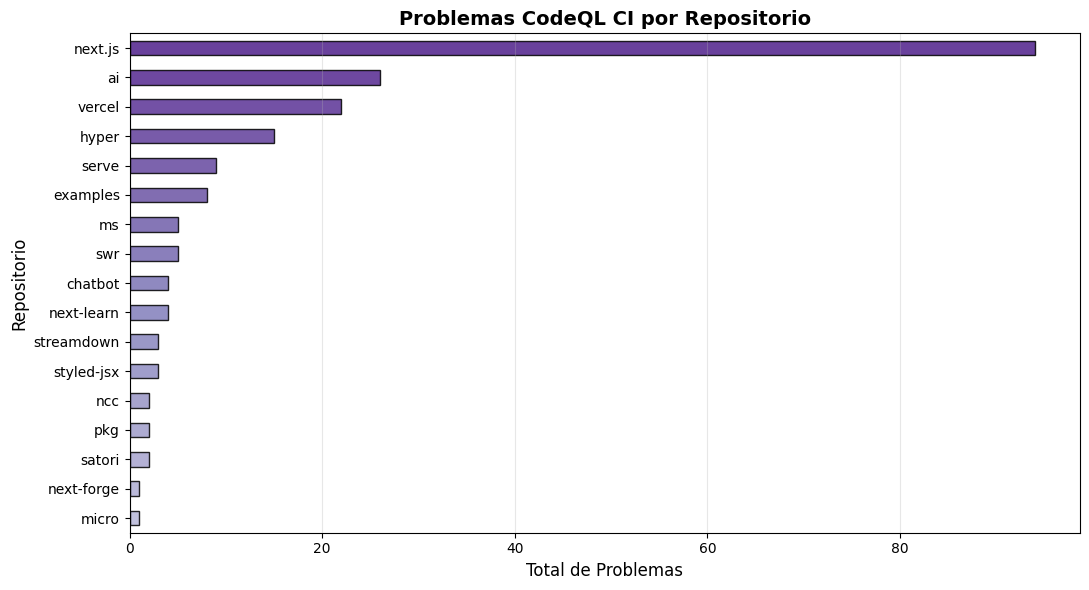

Datos de CI por repositorio exportados a: /workspaces/Proyecto-Ciberseguridad/results/ci-analisis/ci-repo.json


In [32]:
# Gráfico: Problemas por repositorio (CodeQL)
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    issues_por_repo = df_codeql['repo'].value_counts().sort_values(ascending=True)

    colores_gradiente = plt.cm.Purples(
        np.linspace(0.4, 0.9, len(issues_por_repo)))

    issues_por_repo.plot(
        kind='barh', ax=ax, color=colores_gradiente, edgecolor='black', alpha=0.85)

    ax.set_title('Problemas CodeQL CI por Repositorio',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Problemas', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    df_ci_repo_export = df_codeql['repo'].value_counts().reset_index()
    df_ci_repo_export.columns = ['repo', 'count']

    output_ci_repo_path = RESULTS_FOLDER / "ci-analisis" /"ci-repo.json"
    df_ci_repo_export.to_json(output_ci_repo_path, orient='records', indent=4)
    print(f"Datos de CI por repositorio exportados a: {output_ci_repo_path}")

else:
    print("No hay datos disponibles para graficar")

En el gráfico se presentan las frecuencias ordenadas de mayor a menor de los problemas relacionados a CI, donde destaca el repositorio de next.js, presentando alrededor de 100 problemas, siendo la frecuencia significativamente mayor del conjunto. 

In [33]:
# Top 5 reglas más comunes
if len(df_codeql) > 0:
    top_rules = df_codeql['rule_id'].value_counts().head(5)

    print("\nTop 5 Reglas de Seguridad Más Frecuentes:")
    print("=" * 70)
    
    export_ci_rules = []
    
    for idx, (rule, count) in enumerate(top_rules.items(), 1):
        porcentaje = (count / len(df_codeql)) * 100
        print(f"{idx:2d}. {rule:40s} {count:3d} ({porcentaje:5.1f}%)")
        
        export_ci_rules.append({
            "rule_id": rule,
            "count": int(count),
            "percentage": round(porcentaje, 1)
        })

    output_ci_rules_path = RESULTS_FOLDER / "ci-analisis" / "ci-reglas.json"
    with open(output_ci_rules_path, 'w', encoding='utf-8') as f:
        json.dump(export_ci_rules, f, indent=4)
        
    print(f"\nDatos de top reglas CI exportados a: {output_ci_rules_path}")

else:
    print("No hay datos disponibles")


Top 5 Reglas de Seguridad Más Frecuentes:
 1. actions/missing-workflow-permissions     158 ( 76.7%)
 2. actions/unpinned-tag                      42 ( 20.4%)
 3. actions/untrusted-checkout/medium          4 (  1.9%)
 4. actions/code-injection/medium              1 (  0.5%)
 5. actions/unnecessary-use-of-advanced-config   1 (  0.5%)

Datos de top reglas CI exportados a: /workspaces/Proyecto-Ciberseguridad/results/ci-analisis/ci-reglas.json


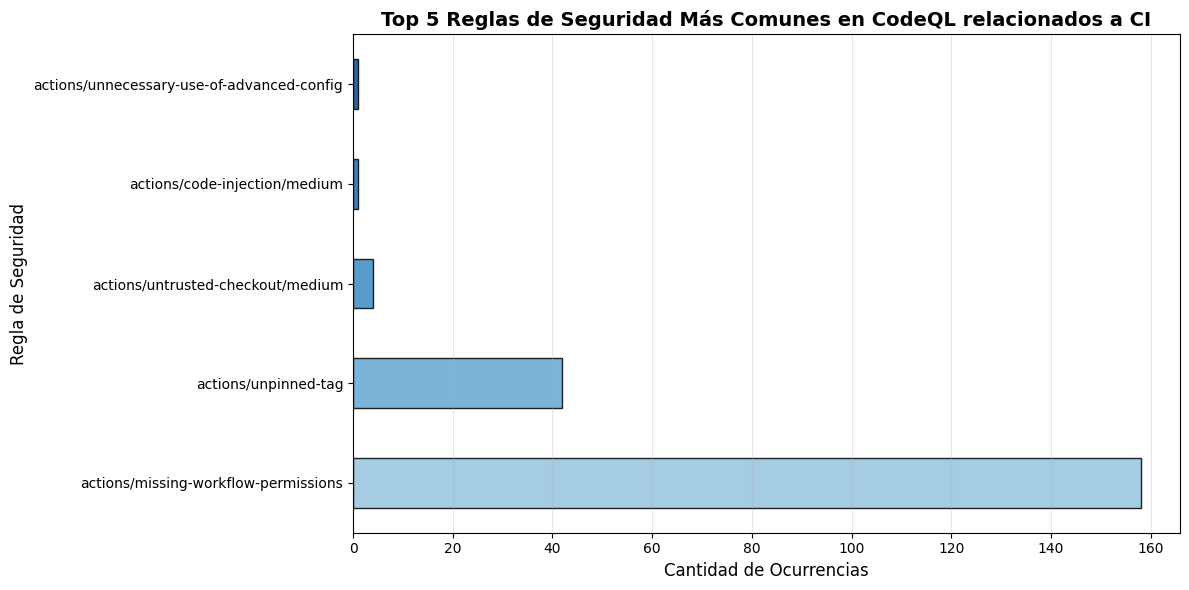

In [34]:
# Gráfico: Top 5 reglas más comunes
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))

    top_rules = df_codeql['rule_id'].value_counts().head(5)

    colores_gradiente = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_rules)))

    top_rules.plot(kind='barh', ax=ax, color=colores_gradiente,
                   edgecolor='black', alpha=0.85)

    ax.set_title('Top 5 Reglas de Seguridad Más Comunes en CodeQL relacionados a CI',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Ocurrencias', fontsize=12)
    ax.set_ylabel('Regla de Seguridad', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para graficar")

Posteriormente se encuentran las 5 reglas más comunes relacionadas a CI:
1. **actions/missing-workflow-permissions:** El problema más frecuente corresponde a no definir verbalmente los permisos que contiene el CI. Por tanto, heredan los permisos de la organización que los creó. Es por ello que se recomienda la definición de los permisos, además de utilizar el principio de mínimo privilegio para minimizar el posible daño.
2. **actions/unpinned-tag:** Hace referencia a asociar acciones a tags, la cual puede no estar fijada, permitiendo la ejecución de una acción no autorizada. Para mitigarlo, se recomienda la utilización del SHA del commit, ya que, es inmutable y única.
3. **actions/unstrusted-checkout/medium:** Utilización de triggers como pull_request_target o issue_comment seguido de un checkout puede permitir la ejecución de código ajeno. Por tanto se recomienda no utilizarlo a menos que sea necesario, utilizar menos privilegios, y usar etiquetas para manejar el contexto de ejecución correctamente.
4. **actions/code-injection/medium:** Hace referencia a permitir el user-input en Github Actions, ya que, puede permitir infiltrar los secrets utilizados u obtener el token de autorización, dando permisos de escritura a agentes externos. Es por ello que se recomienda evitar el user-input en lo posible, y en caso de ser necesario, utilizar una variable de entorno intermedia y después utilizarla como variable en el script. Además de limitar los permisos del token para reducir el posible daño.
5. **actions/unnecessary-use-of-advanced-config:** Corresponde a una recomendación de CodeQL, donde menciona que sí no se utilizan recomendaciones avanzadas, se recomienda dejar la por defecto.